<a href="https://colab.research.google.com/github/babiologa/Bioestat-stica/blob/main/Semin%C3%A1rio01.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Palmer Penguins — dados de três espécies de pinguins (Adelie, Chinstrap, Gentoo) coletados na Estação Palmer, na Antártida, pela Dra. Kristen Gorman (Palmer Station LTER / Long Term Ecological Research Network).

Origem: pesquisa de campo publicada em Gorman, Williams & Fraser (2014), PLoS ONE.
Disponibilizado publicamente no repositório GitHub allisonhorst/palmerpenguins e também no Kaggle.

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

In [ ]:
url = "https://raw.githubusercontent.com/allisonhorst/palmerpenguins/master/inst/extdata/penguins.csv"
df = pd.read_csv(url)

df = df.dropna().reset_index(drop=True)

df.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,year
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,male,2007
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,female,2007
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,female,2007
3,Adelie,Torgersen,36.7,19.3,193.0,3450.0,female,2007
4,Adelie,Torgersen,39.3,20.6,190.0,3650.0,male,2007


In [ ]:
print("Número de observações:", df.shape[0])
print("Número de variáveis>", df.shape[1])
print("\nVariáveis disponíveis:")
print(df.columns.tolist())

df.info()

Número de observações: 333
Número de variáveis> 8

Variáveis disponíveis:
['species', 'island', 'bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g', 'sex', 'year']
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 333 entries, 0 to 332
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            333 non-null    object 
 1   island             333 non-null    object 
 2   bill_length_mm     333 non-null    float64
 3   bill_depth_mm      333 non-null    float64
 4   flipper_length_mm  333 non-null    float64
 5   body_mass_g        333 non-null    float64
 6   sex                333 non-null    object 
 7   year               333 non-null    int64  
dtypes: float64(4), int64(1), object(3)
memory usage: 20.9+ KB


## Descrição dos dados

Os dados foram coletados na Estação Palmer (Antártida) pela pesquisadora Dra. Kristen Gorman,
em parceria com o Palmer Station Long Term Ecological Research Network (LTER), e reúnem
medidas morfológicas de três espécies de pinguins: *Pygoscelis adeliae* (Adelie),
*Pygoscelis antarcticus* (Chinstrap) e *Pygoscelis papua* (Gentoo).

**Variáveis qualitativas (categóricas):**
- `species`: espécie do pinguim (nominal)
- `island`: ilha onde foi observado (nominal)
- `sex`: sexo do animal (nominal)

**Variáveis quantitativas:**
- `bill_length_mm`: comprimento do bico em mm (contínua)
- `bill_depth_mm`: profundidade do bico em mm (contínua)
- `flipper_length_mm`: comprimento da nadadeira em mm (contínua)
- `body_mass_g`: massa corporal em gramas (contínua)
- `year`: ano de observação (discreta)

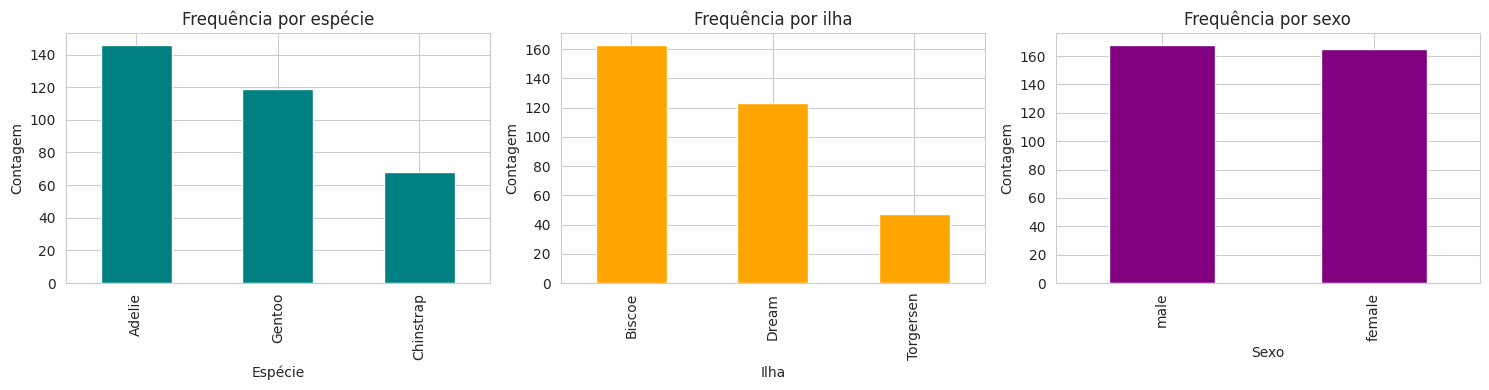

species
Adelie       43.843844
Gentoo       35.735736
Chinstrap    20.420420
Name: proportion, dtype: float64


In [11]:
import pandas as pd
import matplotlib.pyplot as plt

url = "https://raw.githubusercontent.com/allisonhorst/palmerpenguins/master/inst/extdata/penguins.csv"
df = pd.read_csv(url)
df = df.dropna().reset_index(drop=True)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

df['species'].value_counts().plot(kind="bar", ax=axes[0], color="teal")
axes[0].set_title("Frequência por espécie")
axes[0].set_xlabel("Espécie")
axes[0].set_ylabel("Contagem")

df["island"].value_counts().plot(kind="bar", ax=axes[1], color="orange")
axes[1].set_title("Frequência por ilha")
axes[1].set_xlabel("Ilha")
axes[1].set_ylabel("Contagem")

df["sex"].value_counts().plot(kind="bar", ax=axes[2], color="purple")
axes[2].set_title("Frequência por sexo")
axes[2].set_xlabel("Sexo")
axes[2].set_ylabel("Contagem")

plt.tight_layout()
plt.show()

print(df["species"].value_counts(normalize=True) * 100)

In [ ]:
variaveis_quant = ["bill_length_mm", "bill_depth_mm", "flipper_length_mm", "body_mass_g"]

resumo = df[variaveis_quant].describe().T
resumo["IQR"] = resumo["75%"] - resumo["25%"]
resumo

,count,mean,std,min,25%,50%,75%,max,IQR
bill_length_mm,333.0,43.992793,5.468668,32.1,39.5,44.5,48.6,59.6,9.1
bill_depth_mm,333.0,17.164865,1.969235,13.1,15.6,17.3,18.7,21.5,3.1
flipper_length_mm,333.0,200.966967,14.015765,172.0,190.0,197.0,213.0,231.0,23.0
body_mass_g,333.0,4207.057057,805.215802,2700.0,3550.0,4050.0,4775.0,6300.0,1225.0


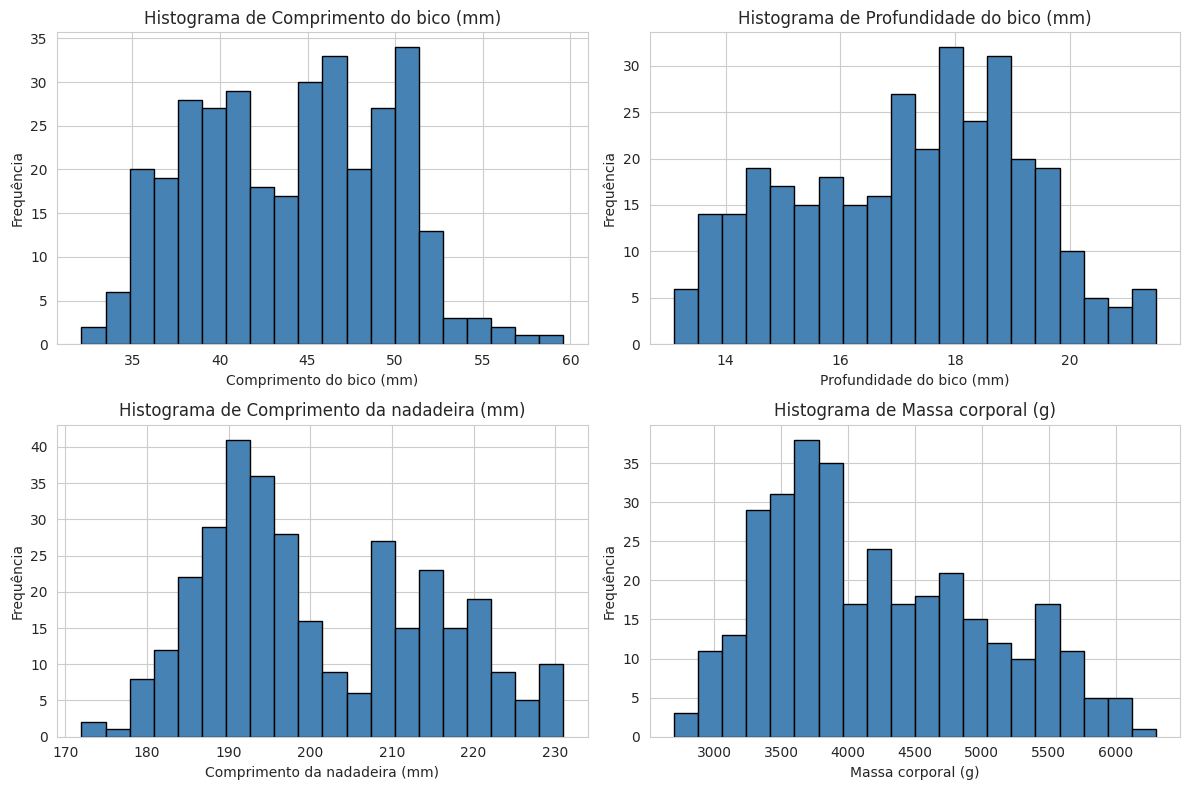

In [12]:
import pandas as pd
import matplotlib.pyplot as plt

url = "https://raw.githubusercontent.com/allisonhorst/palmerpenguins/master/inst/extdata/penguins.csv"
df = pd.read_csv(url)
df = df.dropna().reset_index(drop=True)

variaveis_quant = ["bill_length_mm", "bill_depth_mm", "flipper_length_mm", "body_mass_g"]

label_map_quant = {
    "bill_length_mm": "Comprimento do bico (mm)",
    "bill_depth_mm": "Profundidade do bico (mm)",
    "flipper_length_mm": "Comprimento da nadadeira (mm)",
    "body_mass_g": "Massa corporal (g)"
}

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for i, var in enumerate(variaveis_quant):
  axes[i].hist(df[var], bins=20, color="steelblue", edgecolor="black")
  axes[i].set_title(f"Histograma de {label_map_quant[var]}")
  axes[i].set_xlabel(label_map_quant[var])
  axes[i].set_ylabel("Frequência")

plt.tight_layout()
plt.show()

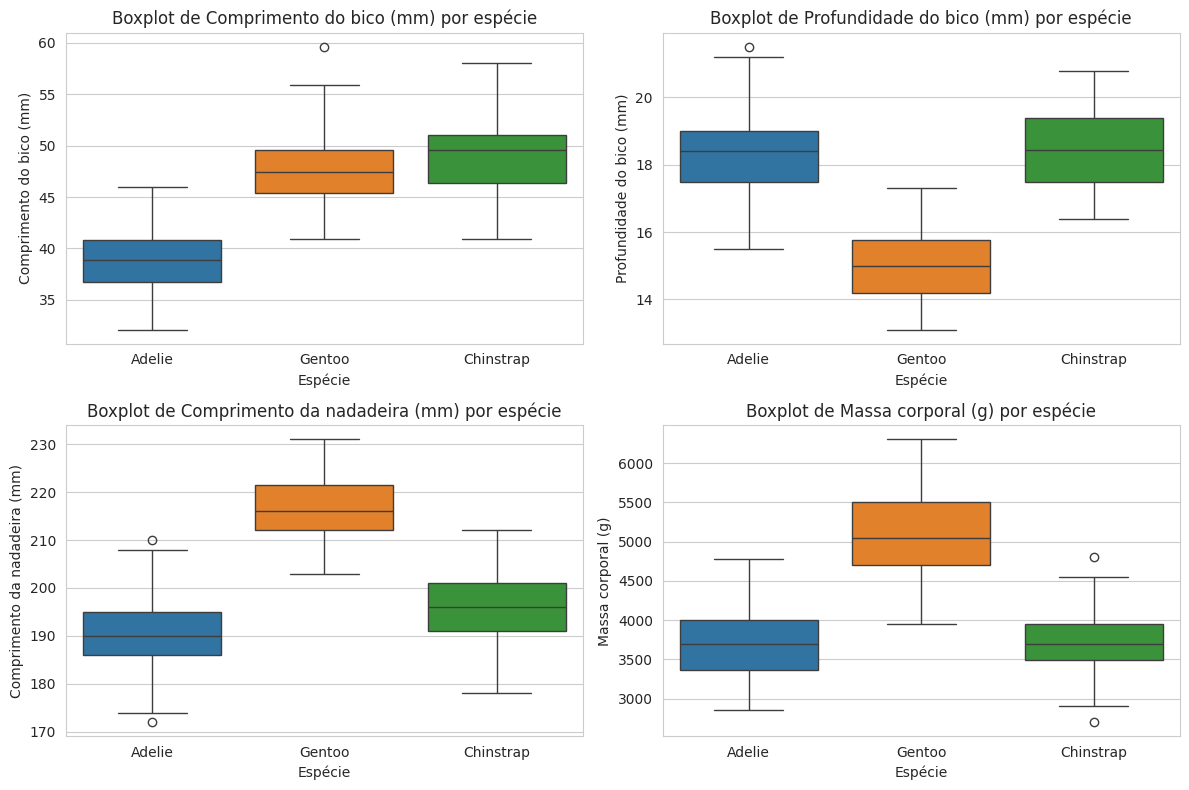

In [15]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

url = "https://raw.githubusercontent.com/allisonhorst/palmerpenguins/master/inst/extdata/penguins.csv"
df = pd.read_csv(url)
df = df.dropna().reset_index(drop=True)

variaveis_quant = ["bill_length_mm", "bill_depth_mm", "flipper_length_mm", "body_mass_g"]

label_map_quant = {
    "bill_length_mm": "Comprimento do bico (mm)",
    "bill_depth_mm": "Profundidade do bico (mm)",
    "flipper_length_mm": "Comprimento da nadadeira (mm)",
    "body_mass_g": "Massa corporal (g)"
}

fig, axes = plt.subplots(2,2, figsize=(12,8))
axes = axes.flatten()

for i, var in enumerate(variaveis_quant):
  sns.boxplot(data=df, x="species", y=var, ax=axes[i], hue="species", legend=False)
  axes[i].set_title(f"Boxplot de {label_map_quant[var]} por espécie")
  axes[i].set_xlabel("Espécie")
  axes[i].set_ylabel(label_map_quant[var])

plt.tight_layout()
plt.show()

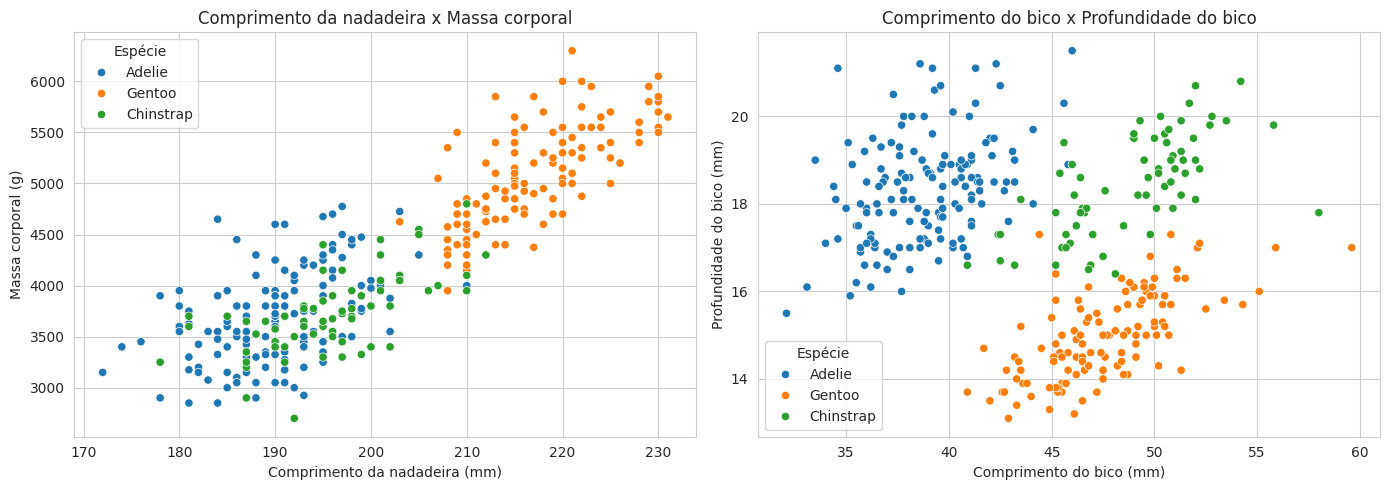

In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

url = "https://raw.githubusercontent.com/allisonhorst/palmerpenguins/master/inst/extdata/penguins.csv"
df = pd.read_csv(url)
df = df.dropna().reset_index(drop=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter plot 1
sns.scatterplot(data=df, x="flipper_length_mm", y="body_mass_g",
                hue="species", ax=axes[0])
axes[0].set_title("Comprimento da nadadeira x Massa corporal")
axes[0].set_xlabel("Comprimento da nadadeira (mm)")
axes[0].set_ylabel("Massa corporal (g)")
axes[0].legend(title="Espécie")
# Scatter plot 2
sns.scatterplot(data=df, x="bill_length_mm", y="bill_depth_mm",
                hue="species", ax=axes[1])
axes[1].set_title("Comprimento do bico x Profundidade do bico")
axes[1].set_xlabel("Comprimento do bico (mm)")
axes[1].set_ylabel("Profundidade do bico (mm)")
axes[1].legend(title="Espécie")

plt.tight_layout()
plt.show()

In [ ]:
r, p_valor = stats.pearsonr(df["flipper_length_mm"], df["body_mass_g"])
print(f"Coeficiente de Pearson (nadadeira x massa corporal): r = {r:.3f}")
print(f"p-valor: {p_valor:.2e}")

matriz_corr = df[variaveis_quant].corr(method="pearson")
matriz_corr

Coeficiente de Pearson (nadadeira x massa corporal): r = 0.873
p-valor: 3.13e-105


,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g
bill_length_mm,1.000000,-0.228626,0.653096,0.589451
bill_depth_mm,-0.228626,1.000000,-0.577792,-0.472016
flipper_length_mm,0.653096,-0.577792,1.000000,0.872979
body_mass_g,0.589451,-0.472016,0.872979,1.000000


Equação da reta: massa =  50.153266 * nadadeira + -5872.092683
Coeficiente de determinação (R^2): 0.762092
p-valor: 3.132836e-105


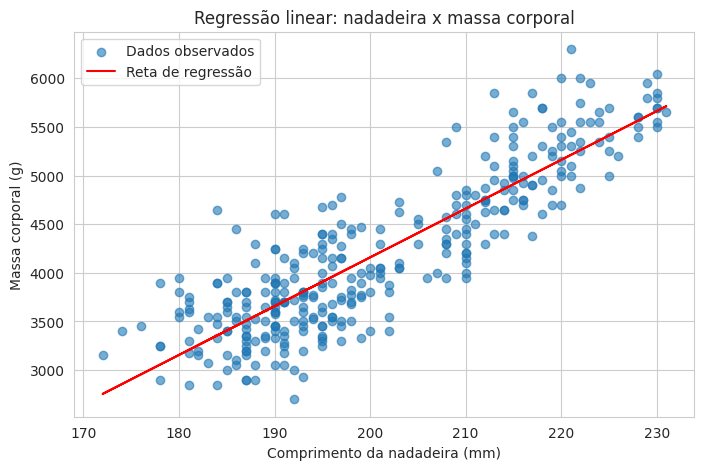

In [ ]:
x = df["flipper_length_mm"]
y = df["body_mass_g"]

reg = stats.linregress(x, y)

print(f"Equação da reta: massa = {reg.slope: 2f} * nadadeira + {reg.intercept: 2f}")
print(f"Coeficiente de determinação (R^2): {reg.rvalue**2:3f}")
print(f"p-valor: {reg.pvalue:2e}")

plt.figure(figsize=(8, 5))
plt.scatter(x, y, alpha=0.6, label="Dados observados")
plt.plot(x, reg.intercept +reg.slope * x, color="red", label="Reta de regressão")
plt.xlabel("Comprimento da nadadeira (mm)")
plt.ylabel("Massa corporal (g)")
plt.title("Regressão linear: nadadeira x massa corporal")
plt.legend()
plt.show()

## Conclusões

- As três espécies apresentam distribuições distintas de massa corporal e dimensões do bico,
  o que sugere diferenças morfológicas relevantes entre elas (visível nos boxplots).
- Existe uma correlação positiva forte entre o comprimento da nadadeira e a massa corporal
  (r próximo de 0,87), indicando que pinguins com nadadeiras maiores tendem a ser mais pesados.
- O modelo de regressão linear simples explica uma proporção considerável da variação da massa
  corporal a partir do comprimento da nadadeira (R² apresentado na Célula 12).
- Os histogramas mostram que a maioria das variáveis quantitativas tem distribuição
  aproximadamente simétrica, com algumas variações entre espécies.